In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter

In [92]:
plt.rcParams["figure.figsize"] = (16, 3)
plt.rcParams["axes.grid"] = True

In [93]:
ds = pd.read_csv("../csv/session.csv", delimiter=';', parse_dates=['timestamp'], index_col=0)
dg = pd.read_csv("../csv/global_returns.csv", delimiter=';', parse_dates=['timestamp'], index_col=0)
dt = pd.read_csv("../csv/processing_timings.csv", delimiter=';', parse_dates=['timestamp'])
di = pd.read_csv("../csv/issues.csv", delimiter=';', parse_dates=['timestamp'], index_col=0)


# Session data

In [94]:
def describe(frames, types, labels):
    """
    abbreaviated version of pd.describe in horizontal layout
    
    needs 3 *size-matched* lists
    
    :param frames: a list of frames to describe
    :param types: list of event types to describe
    :param labels: labels for values of each event types
    """
    storage = []
    
    for frame, type_n, label in zip(frames, types, labels):
        
        description = frame[frame.type == type_n].describe()
        description.rename(columns={'value': label}, inplace=True)
        storage.append(description)
        
    return pd.concat(storage, axis=1).loc[['mean', 'min', 'max', 'std', 'count']].transpose()

In [95]:
print(f"ALS start time: {str(ds.index[0])}")
print(f"ALS stop time : {str(ds.index[-1])}")

ALS start time: 2026-05-31 20:42:08.901483
ALS stop time : 2026-05-31 20:53:20.201520


# Alignment

### translations

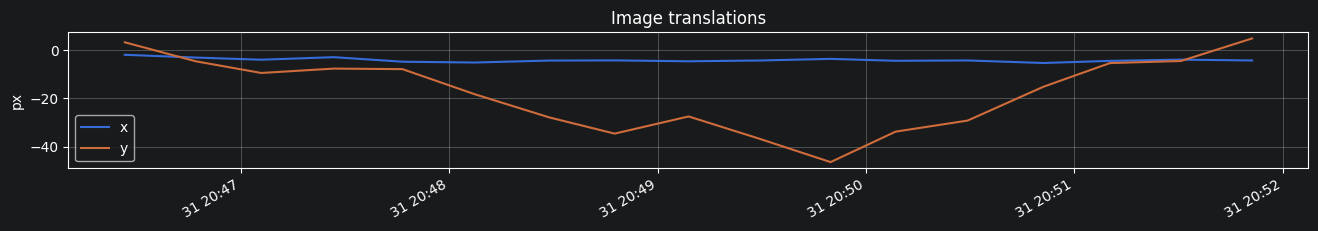

,mean,min,max,std,count
translation x (px),-3.981790,-5.220377,-1.803352,0.840217,17.0
translation y (px),-17.649722,-46.486718,4.995807,15.440416,17.0


In [96]:
ax = ds[ds.type == "x_trans"].plot(title="Image translations",
                                             sharex=True,
                                             y='value',
                                             label="x",
                                             ylabel="px",
                                             figsize=(16, 2))

ds[ds.type == "y_trans"].plot( y='value', label="y", ax=ax, xlabel="")



plt.show()

all_trans = [ds[(ds.type == "x_trans")], ds[(ds.type == "y_trans")]]

describe(all_trans, ['x_trans', 'y_trans'], ['translation x (px)', 'translation y (px)'])

### rotations

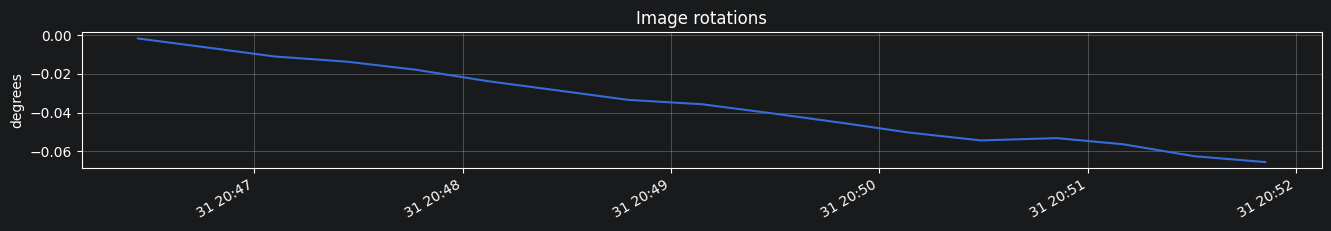

,mean,min,max,std,count
rotation (°),-0.035367,-0.065562,-0.001784,0.020338,17.0


In [97]:
import math
rot=ds[ds.type == 'rotation'].copy()
rot['value'] = rot['value'].apply(lambda v:  math.degrees(v))


rot.plot(title="Image rotations",
    y='value', legend=False, ylabel="degrees", xlabel='', figsize=(16, 2))
plt.show()

describe([rot], ['rotation'], ['rotation (°)'])

### scaling

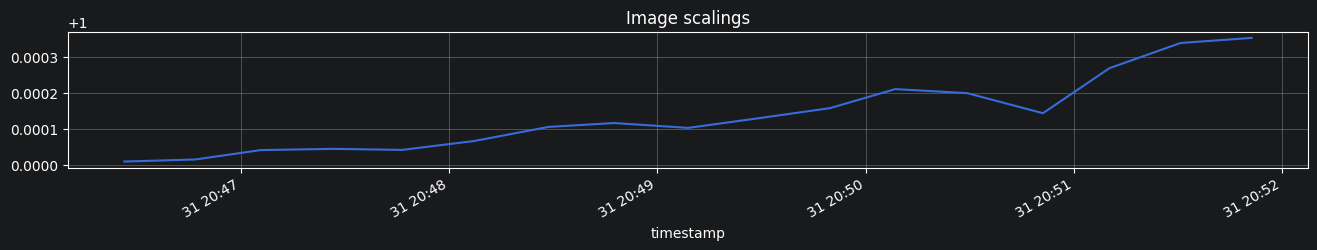

,mean,min,max,std,count
scale,1.000138,1.00001,1.000353,0.000106,17.0


In [98]:
scale = ds[ds.type == 'scale']
scale.plot(y="value", legend=False, figsize=(16, 2), title="Image scalings")
plt.show()

describe([scale], ['scale'], ['scale'])


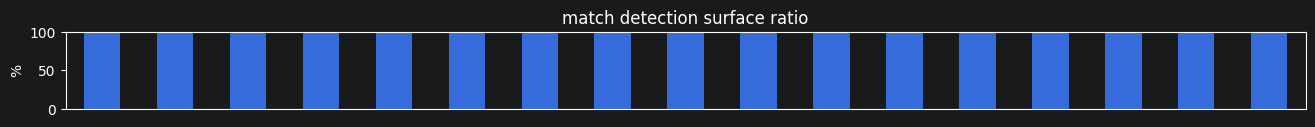

In [99]:
rat=ds[ds.type == 'ratio'].copy()
rat['value'] = rat['value'].apply(lambda v:  v * 100)

rat.plot(
    kind="bar", y='value', label='ratio',
    ylabel="%",
    title="match detection surface ratio",
    xticks=[], xlabel="", legend=False, figsize=(16,1), ylim=(0, 100),
    grid=False
)
plt.show()

### matches

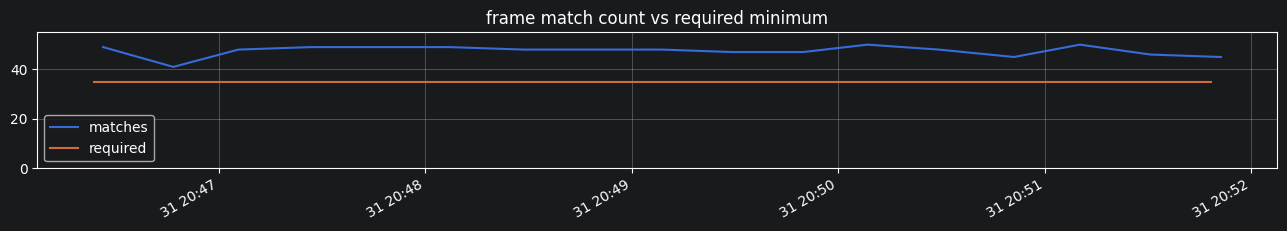

,mean,min,max,std,count
matches,47.470588,41.0,50.0,2.239354,17.0


In [100]:
matches = ds[ds.type == 'matches']
ax = matches.plot(
    y='value',
    title="frame match count vs required minimum",
    ylim=(0,ds[ds.type == 'matches'].value.max() + 5),
    xlabel="",
    label="matches",
    figsize=(16, 2)
)

ds[ds.type == 'req_matches'].plot(ax=ax, y='value', label='required', xlabel='')

plt.show()

describe([matches], ['matches'], ['matches'])

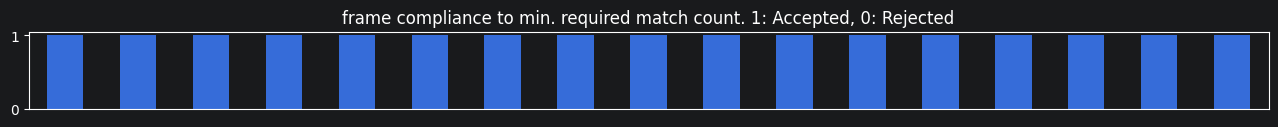

In [101]:
ds[ds.type == 'align'].plot(
    kind="bar",
    grid=False,
    xticks=[], xlabel="",
    legend=False,
    figsize=(16,1),
    title="frame compliance to min. required match count. 1: Accepted, 0: Rejected"
)
plt.show()

In [102]:
ds[ds.type == 'align'].value.transform(lambda x: "accepted" if x == 1. else "rejected").value_counts()

value
accepted    17
Name: count, dtype: int64

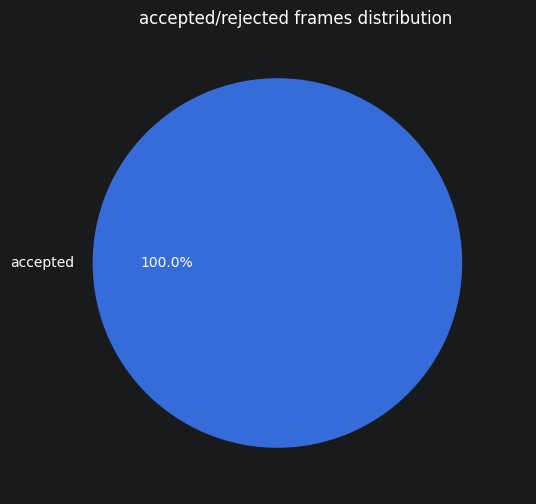

In [103]:
data = ds[ds.type == 'align'].value.transform(lambda x: "accepted" if x == 1. else "rejected").value_counts()
data.plot(
    kind="pie",
    autopct='%1.1f%%',
    title="accepted/rejected frames distribution",
    ylabel="", explode=(([0.1 for x in range(len(data))])), figsize=(6,6)
)
plt.show()

# Issues

## Global

In [104]:
pd.DataFrame(di.level.value_counts())

,count
level,


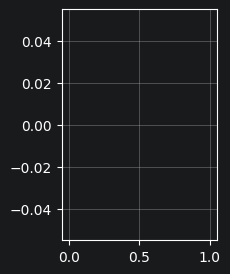

In [105]:
di.level.hist(figsize=(2,3))
plt.show()

## Errors

In [106]:
pd.options.display.max_colwidth = 256
pd.options.display.max_rows = 1024
di[di.level == "ERROR"].head()

,thread,module,level,message
timestamp,,,,


## Warnings

In [107]:
di[di.level == "WARNING"].head()

,thread,module,level,message
timestamp,,,,


# Queues

In [108]:
def plot_queue_size(data, title):
    
    data.plot(kind='bar', title=title,
              xlabel="",
              figsize=(16, 2),
              legend=False, xticks=[])
    plt.show()

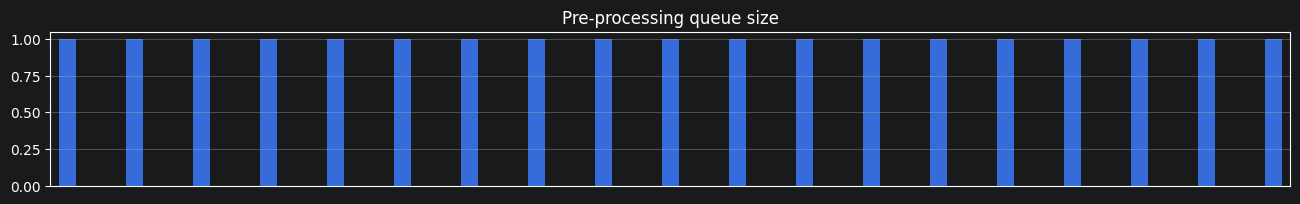

In [109]:
plot_queue_size(ds[ds.type == 'q_pre'], "Pre-processing queue size")

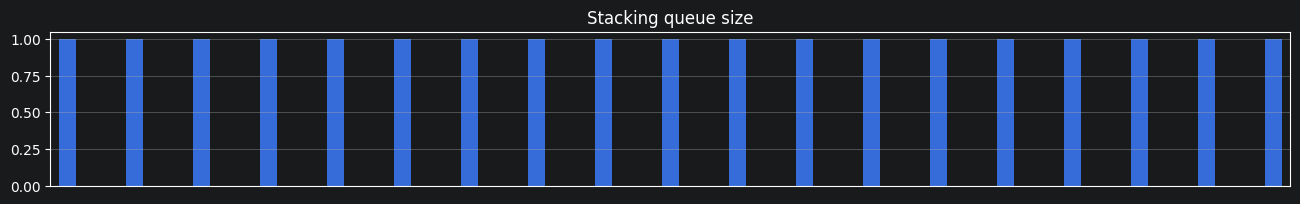

In [110]:
plot_queue_size(ds[ds.type == 'q_stack'], "Stacking queue size")

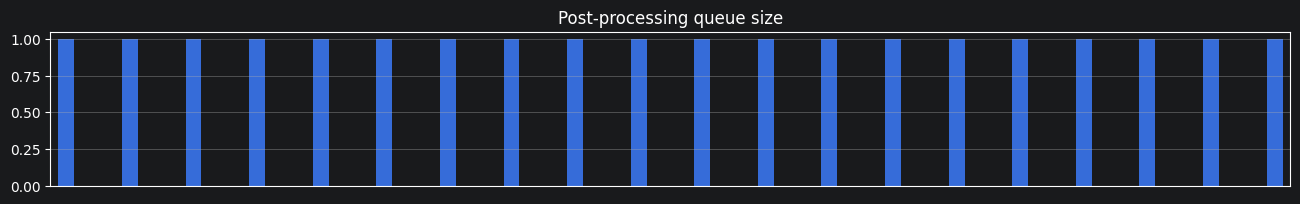

In [111]:
plot_queue_size(ds[ds.type == 'q_post'], "Post-processing queue size")

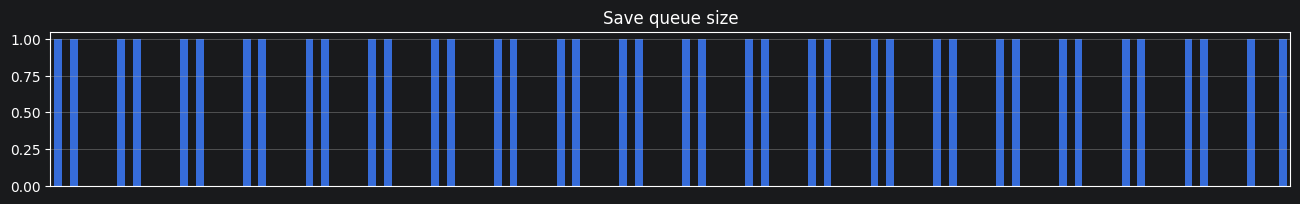

In [112]:
plot_queue_size(ds[ds.type == 'q_save'], "Save queue size")

# Timings

## Frame total processing time

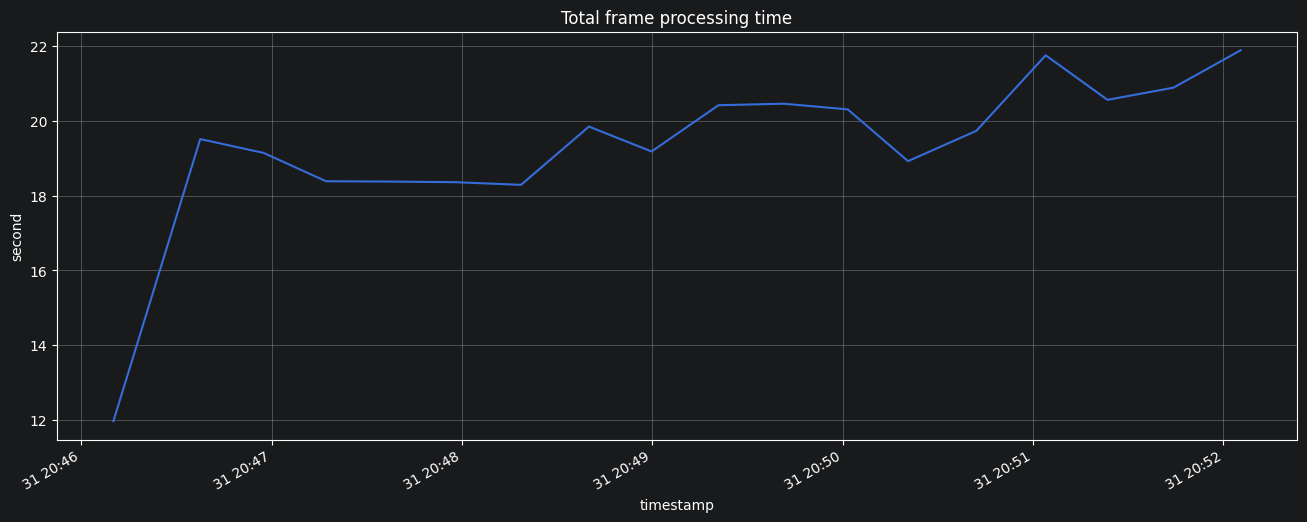

,mean,min,max,std,count
Total frame processing time,19.332889,11.968,21.888,2.148726,18.0


In [113]:
total = ds[ds.type == 'frm_total']
total.plot(title="Total frame processing time",
                                ylabel="second", figsize=(16, 6), legend=False)
plt.show()
describe([total], ['frm_total'], ['Total frame processing time'])

In [114]:
def plot_timings(name_dict, title):

    pre_data = dt[dt['name'].isin(name_dict.keys())].copy()
    
    for k, v in name_dict.items():
        pre_data.loc[pre_data['name'] == k, 'name'] = v
        
    pre_data = pre_data.rename(columns={'name': 'process'})
    
    sns.lineplot(data=pre_data, x='timestamp', y='elapsed', hue='process').set(title=title, ylabel='ms')
    plt.plot()
    return pre_data

    

## Preprocessing timings

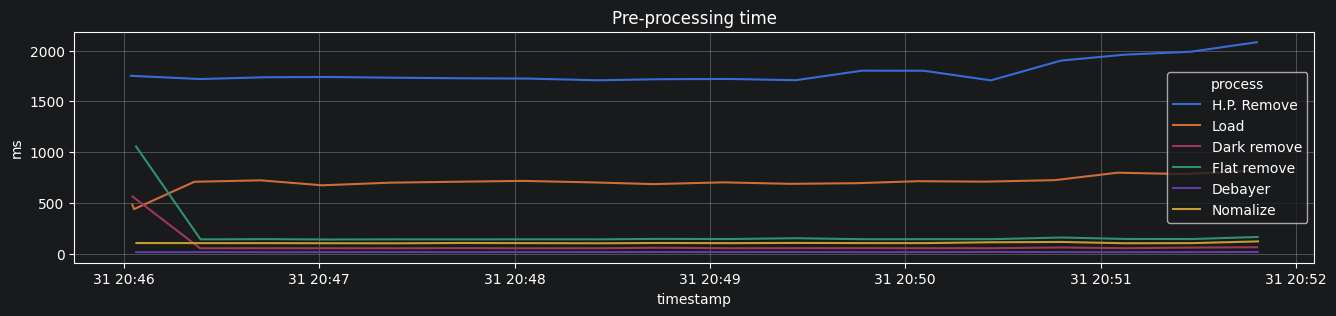

In [115]:
prepro_name_dict = {
    'HotPixelRemover.process_image()': 'H.P. Remove',
    'RemoveDark.process_image()': 'Dark remove',
    'Debayer.process_image()': 'Debayer',
    'Standardize.process_image()': 'Nomalize',
    'RemoveFlat.process_image()': 'Flat remove',
    'read_disk_image()': 'Load'
}

pre_data = plot_timings(prepro_name_dict, "Pre-processing time")



In [116]:
pre_data.groupby('process').describe().iloc[:, [1,3,7,0,2]]

timestamp                                   \
                                   mean                         25%  std   
process                                                                    
Dark remove  2026-05-31 20:48:55.350866  2026-05-31 20:47:28.583180  NaN   
Debayer      2026-05-31 20:48:55.560719  2026-05-31 20:47:28.737873  NaN   
Flat remove  2026-05-31 20:48:55.546078  2026-05-31 20:47:28.723552  NaN   
H.P. Remove  2026-05-31 20:48:55.268008  2026-05-31 20:47:28.530349  NaN   
Load         2026-05-31 20:48:44.628850  2026-05-31 20:47:11.372407  NaN   
Nomalize     2026-05-31 20:48:55.666048  2026-05-31 20:47:28.840313  NaN   

                                               
            count                         min  
process                                        
Dark remove    18  2026-05-31 20:46:02.726243  
Debayer        18  2026-05-31 20:46:03.796140  
Flat remove    18  2026-05-31 20:46:03.782091  
H.P. Remove    18  2026-05-31 20:46:02.163986  
Load           19  2026-05-31 20:46:02.644960  
Nomalize       18  2026-05-31 20:46:03.900255

## Stacking timings

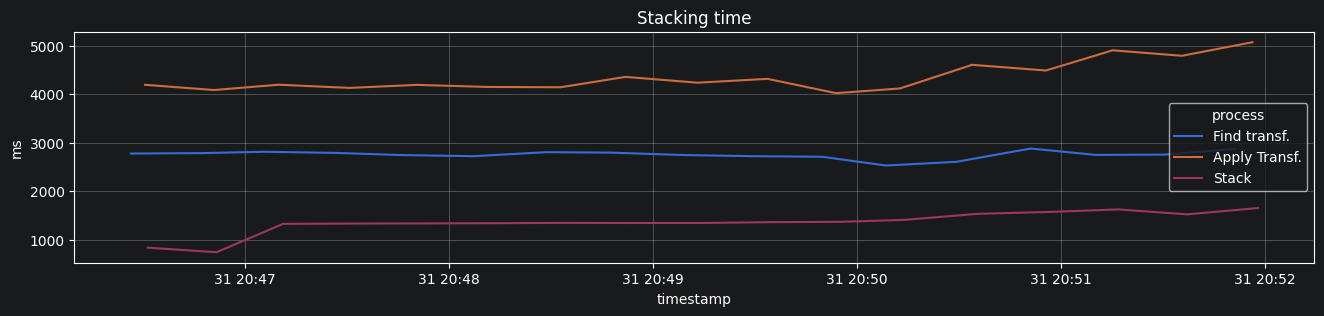

In [117]:
stack_name_dict = {
    "Stacker._find_transformation()": "Find transf.",
    "Stacker._apply_transformation()": "Apply Transf.",
    "Stacker._stack_image()": "Stack"
}

st_data = plot_timings(stack_name_dict, "Stacking time")

In [118]:
st_data.groupby('process').describe().iloc[:, [1,3,7,0,2]]

timestamp                                   \
                                     mean                         25%  std   
process                                                                      
Apply Transf.  2026-05-31 20:49:12.877114  2026-05-31 20:47:50.673371  NaN   
Find transf.   2026-05-31 20:49:08.526930  2026-05-31 20:47:46.484062  NaN   
Stack          2026-05-31 20:49:14.226127  2026-05-31 20:47:52.005253  NaN   

                                                 
              count                         min  
process                                          
Apply Transf.    17  2026-05-31 20:46:30.667333  
Find transf.     17  2026-05-31 20:46:26.476743  
Stack            17  2026-05-31 20:46:31.498995

## Post processing timings

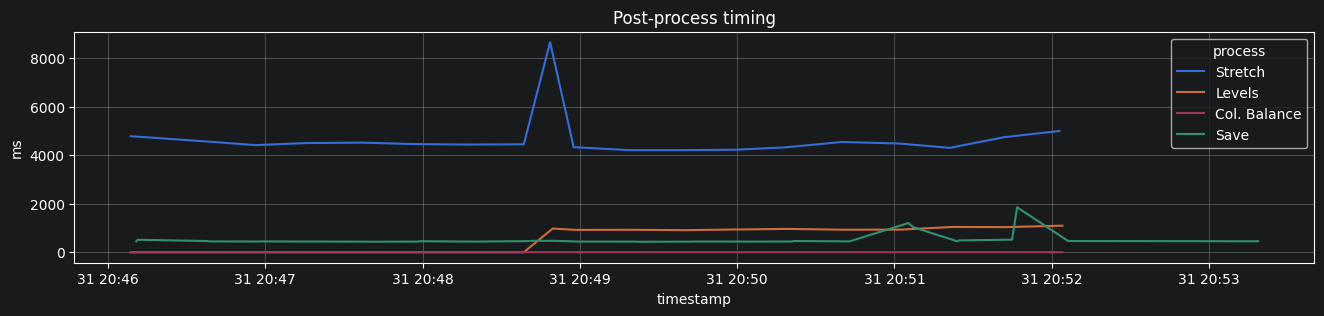

In [119]:
old_new_pp_names_dict = {
    'AutoStretch.process_image()': 'Stretch',
    'Levels.process_image()': 'Levels',
    'ColorBalance.process_image()': 'Col. Balance',
    'ImageSaver._save_image()': 'Save'
}

po_data = plot_timings(old_new_pp_names_dict, "Post-process timing")

In [120]:
po_data.groupby('process').describe().iloc[:, [1,3,7,0,2]]

timestamp                                   \
                                    mean                         25%  std   
process                                                                     
Col. Balance  2026-05-31 20:49:07.674990  2026-05-31 20:47:46.566595  NaN   
Levels        2026-05-31 20:49:07.673886  2026-05-31 20:47:46.565257  NaN   
Save          2026-05-31 20:49:16.269746  2026-05-31 20:47:48.669825  NaN   
Stretch       2026-05-31 20:49:07.112071  2026-05-31 20:47:46.563825  NaN   

                                                
             count                         min  
process                                         
Col. Balance    19  2026-05-31 20:46:08.694155  
Levels          19  2026-05-31 20:46:08.693261  
Save            39  2026-05-31 20:46:10.741785  
Stretch         19  2026-05-31 20:46:08.692303